In [80]:
import os
import pandas as pd
coin_name = "BTC"
time_frame = "5m"
months = 72
version = "V3"
ASIAN_PATH = fr"C:\Users\User\Desktop\Crypto\{coin_name}_{time_frame}_{months}M_ASIANsession.parquet"
US_PATH = fr"C:\Users\User\Desktop\Crypto\{coin_name}_{time_frame}_{months}M_USsession.parquet"
ALL_PATH = fr"C:\Users\User\Desktop\Crypto\{coin_name}_{time_frame}_{months}M_UTC.parquet"
asian_data = pd.read_parquet(ASIAN_PATH)
all_data = pd.read_parquet(ALL_PATH)
us_data = pd.read_parquet(US_PATH)
asian_data["dt_utc"] = asian_data["dt_utc"].dt.tz_localize(None)
asian_data["dt_utc_date"] = asian_data["dt_utc"].dt.date
all_data["dt_utc"] = all_data["dt_utc"].dt.tz_localize(None)
all_data["dt_utc_date"] = all_data["dt_utc"].dt.date
us_data["dt_utc"] = us_data["dt_utc"].dt.tz_localize(None)
us_data["dt_utc_date"] = us_data["dt_utc"].dt.date
asian_data.head()


,ts,open,high,low,close,vol,dt_utc,dt_utc_date
0,1585705200000,6287.00,6290.71,6281.00,6281.01,436.502,2020-04-01 01:40:00,2020-04-01
1,1585705500000,6281.00,6297.69,6280.00,6290.00,748.336,2020-04-01 01:45:00,2020-04-01
2,1585705800000,6290.00,6295.03,6283.56,6284.92,463.554,2020-04-01 01:50:00,2020-04-01
3,1585706100000,6284.93,6290.00,6280.59,6287.20,443.373,2020-04-01 01:55:00,2020-04-01
4,1585706400000,6287.05,6299.35,6281.86,6296.59,597.877,2020-04-01 02:00:00,2020-04-01


In [121]:
asian_day_group = asian_data.groupby("dt_utc_date").agg({
    "open": "first",
    "high": "max",
    "low": "min",
    "close": "last",
}).reset_index()
all_day_group = all_data.groupby("dt_utc_date").agg({
    "open": "first",
    "high": "max",
    "low": "min",
    "close": "last",
}).reset_index()
us_day_group = us_data.groupby("dt_utc_date").agg({
    "open": "first",
    "high": "max",
    "low": "min",
    "close": "last",
}).reset_index()
asian_day_group["date"] = pd.to_datetime(asian_day_group["dt_utc_date"]).dt.tz_localize(None)
asian_day_group["date"] = pd.to_datetime(asian_day_group["date"]).dt.date
asian_day_group.set_index("dt_utc_date", inplace=True)
all_day_group["date"] = pd.to_datetime(all_day_group["dt_utc_date"]).dt.tz_localize(None)
all_day_group["date"] = pd.to_datetime(all_day_group["date"]).dt.date
all_day_group.set_index("dt_utc_date", inplace=True)
us_day_group["date"] = pd.to_datetime(us_day_group["dt_utc_date"]).dt.tz_localize(None)
us_day_group["date"] = pd.to_datetime(us_day_group["date"]).dt.date
us_day_group.set_index("dt_utc_date", inplace=True)
import talib
import numpy as np
def cal_indicators(data):
    data["yesterday_range"] = data["high"].shift(1) - data["low"].shift(1)
    data["atr"] = talib.ATR(data["high"], data["low"], data["close"], timeperiod=14)
    data["atr_pct"] = data["atr"] / data["close"]
    data["ema_20"] = talib.EMA(data["close"], timeperiod=20)
    d = 252
    data["atr_1y_1Q"] = data["atr_pct"].rolling(window=d).quantile(0.25)
    data["atr_1y_2Q"] = data["atr_pct"].rolling(window=d).quantile(0.5)
    data["atr_1y_3Q"] = data["atr_pct"].rolling(window=d).quantile(0.75)

    data["yesterday_atr"] = data["atr_pct"].shift(1)
    s = data["yesterday_atr"]
    q1 = data["atr_1y_1Q"].shift(1)
    q2 = data["atr_1y_2Q"].shift(1)
    q3 = data["atr_1y_3Q"].shift(1)
    data["yesterday_atr_Q"] = np.select([s <= q1,(s > q1) & (s <= q2),(s > q2) & (s <= q3),s > q3,],["1Q", "2Q", "3Q", "4Q"],default=np.nan,)
    data["yesterday_MA20_diff"] = data["close"].shift(1) - data["ema_20"].shift(1)
    data["yesterday_above_MA20"] = data["yesterday_MA20_diff"] > 0
    return data
asian_day_group = cal_indicators(asian_day_group)
all_day_group = cal_indicators(all_day_group)
us_day_group = cal_indicators(us_day_group)
import matplotlib.pyplot as plt
def plot_atr_quantiles(group):
    plt.figure(figsize=(12, 6))
    plt.plot(group.index, group["yesterday_atr_Q"], label="Asian Session ATR 1Q")
    # plt.plot(asian_day_group.index, all_day_group["atr_1y_2Q"], label="Asian Session ATR 2Q")
    # plt.plot(asian_day_group.index, asian_day_group["atr_1y_3Q"], label="Asian Session ATR 3Q")
    plt.title("ATR Quantiles Over Time")
    print(group["yesterday_atr_Q"].value_counts())
    print(group["yesterday_above_MA20"].value_counts())

In [7]:
import pandas as pd

trades = pd.read_excel(fr'C:\Users\User\Desktop\JJproject\策略\strong breakout\trades info\BTC_5m_trades_V3.xlsx')
print(trades["entry_time"][0])
trades["entry_date_time"] = trades["entry_time"].dt.tz_localize(None)
print(trades["entry_time"][0])
trades["exit_date_time"] = trades["exit_time"].dt.tz_localize(None)
trades["entry_date"] = trades["entry_date_time"].dt.date
trades["exit_date"] = trades["exit_date_time"].dt.date
trades["entry_time"] = trades["entry_date_time"].dt.strftime("%H:%M")
trades["exit_time"] = trades["exit_date_time"].dt.strftime("%H:%M")
trades["pnl_gross"] = trades["pnl"]
trades["rr_gross"] = trades["pnl_gross"] / (abs(trades["sl_price"] - trades["entry_price"]) * trades["qty"])
trades = trades[["entry_date_time", "exit_date_time", "entry_date", "entry_time", "exit_date", "exit_time", "entry_price", "sl_price", "tp_price", "exit_price", "qty", "side", "pnl_gross", "rr_gross"]]
trades.head()

2022-01-29 03:25:00
2022-01-29 03:25:00


,entry_date_time,exit_date_time,entry_date,entry_time,exit_date,exit_time,entry_price,sl_price,tp_price,exit_price,qty,side,pnl_gross,rr_gross
0,2022-01-29 03:25:00,2022-01-29 04:40:00,2022-01-29,03:25,2022-01-29,04:40,37668.13,37493.83,37877.290,37877.290,0.573723,Side.LONG,120.000000,1.2
1,2022-01-31 07:45:00,2022-01-31 10:55:00,2022-01-31,07:45,2022-01-31,10:55,37155.76,37020.28,37318.336,37318.336,0.746974,Side.LONG,121.440000,1.2
2,2022-02-01 09:00:00,2022-02-01 09:25:00,2022-02-01,09:00,2022-02-01,09:25,39004.50,38525.48,39579.324,38525.480,0.213800,Side.LONG,-102.414400,-1.0
3,2022-02-01 16:05:00,2022-02-01 16:55:00,2022-02-01,16:05,2022-02-01,16:55,38837.37,38566.40,39162.534,39162.534,0.374175,Side.LONG,121.668307,1.2
4,2022-02-03 11:30:00,2022-02-03 12:25:00,2022-02-03,11:30,2022-02-03,12:25,36621.68,36320.00,36983.696,36320.000,0.340118,Side.LONG,-102.606939,-1.0


In [68]:
trades_day_group = trades.groupby("entry_date").agg({
    "pnl_gross": "sum",
    "rr_gross": "sum",}).reset_index()
trades_day_group["date"] = pd.to_datetime(trades_day_group["entry_date"]).dt.date
trades_day_group.set_index("entry_date", inplace=True)
trades_day_group.head()

,pnl_gross,rr_gross,date
entry_date,,,
2022-01-29,120.000000,1.200000,2022-01-29
2022-01-31,121.440000,1.200000,2022-01-31
2022-02-01,19.253907,0.200000,2022-02-01
2022-02-03,-102.606939,-1.000000,2022-02-03
2022-02-04,354.215577,3.446611,2022-02-04


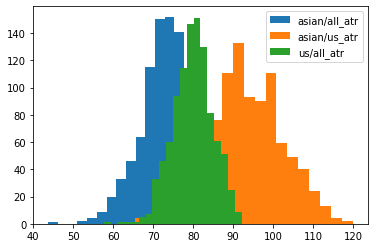

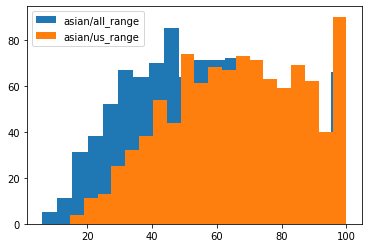

In [126]:
a = trades_day_group.copy()
b = asian_day_group.copy()
c = us_day_group.copy()
d = all_day_group.copy()
merged = b.merge(a, on="date", how="left").dropna(subset=["pnl_gross", "rr_gross"])
merged.head()["date"]

merged = merged.merge(c, on="date", how="left", suffixes=("_asian", "_us"))
merged = merged.merge(d, on="date", how="left")
merged.head()
merged["asian/all_atr"] = 100*merged["yesterday_atr_asian"] / merged["yesterday_atr"]
merged["asian/us_atr"] = 100*merged["yesterday_atr_asian"] / merged["yesterday_atr_us"]
merged["us/all_atr"] = 100*merged["yesterday_atr_us"] / merged["yesterday_atr"]
merged["asian/all_range"] = 100*merged["yesterday_range_asian"] / merged["yesterday_range"]
merged["asian/us_range"] = 100*merged["yesterday_range_asian"] / merged["yesterday_range_us"]
merged["us/all_range"] = 100*merged["yesterday_range_us"] / merged["yesterday_range"]
plt.hist(merged["asian/all_atr"], bins=20)
plt.hist(merged["asian/us_atr"], bins=20)
plt.hist(merged["us/all_atr"], bins=20)
plt.legend(["asian/all_atr", "asian/us_atr", "us/all_atr"])
plt.show()
plt.hist(merged["asian/all_range"], bins=20)
# plt.hist(merged["asian/us_range"], bins=20)
plt.hist(merged["us/all_range"], bins=20)
plt.legend(["asian/all_range", "asian/us_range", "us/all_range"])

### MA對pnl

In [110]:
print(merged["pnl_gross"].mean())
print(merged["rr_gross"].mean())

11.198052928327611
0.09027927743290978


In [116]:
above_MA20_group = merged.groupby("yesterday_above_MA20").agg({
    "pnl_gross": "mean",
    "rr_gross": "mean",
    "date": "count",
    }).reset_index()
print(above_MA20_group)
above_MA20_group = merged.groupby("yesterday_above_MA20_asian").agg({
    "pnl_gross": "mean",
    "rr_gross": "mean",
    "date": "count",
    }).reset_index()
print(above_MA20_group)
above_MA20_group = merged.groupby("yesterday_above_MA20_us").agg({
    "pnl_gross": "mean",
    "rr_gross": "mean",
    "date": "count",
    }).reset_index()
print(above_MA20_group)

   yesterday_above_MA20  pnl_gross  rr_gross  date
0                 False   5.496794  0.050925   472
1                  True  16.126614  0.124300   546
   yesterday_above_MA20_asian  pnl_gross  rr_gross  date
0                       False  11.874374  0.111055   469
1                        True  10.620285  0.072531   549
   yesterday_above_MA20_us  pnl_gross  rr_gross  date
0                    False   5.221178  0.051794   478
1                     True  16.488694  0.124346   540


### ATR對pnl

In [114]:
atr_group = merged.groupby("yesterday_atr_Q").agg({
    "pnl_gross": "mean",
    "rr_gross": "mean",
    "date": "count",

    }).reset_index()
print(atr_group)
atr_group = merged.groupby("yesterday_atr_Q_asian").agg({
    "pnl_gross": "mean",
    "rr_gross": "mean",
    # count
    "date": "count",
    }).reset_index()
print(atr_group)
atr_group = merged.groupby("yesterday_atr_Q_us").agg({
    "pnl_gross": "mean",
    "rr_gross": "mean",
    "date": "count",

    }).reset_index()
print(atr_group)

  yesterday_atr_Q  pnl_gross  rr_gross  date
0              1Q   9.877272  0.071012   375
1              2Q  44.444672  0.261380   221
2              3Q   9.805954  0.116215   214
3              4Q -20.313008 -0.083463   208
  yesterday_atr_Q_asian  pnl_gross  rr_gross  date
0                    1Q  14.162067  0.100688   393
1                    2Q  26.378292  0.175043   216
2                    3Q  -8.272194 -0.005368   200
3                    4Q   8.567720  0.074632   209
  yesterday_atr_Q_us  pnl_gross  rr_gross  date
0                 1Q  16.670688  0.100687   342
1                 2Q  22.224193  0.164454   221
2                 3Q   4.324941  0.074015   247
3                 4Q  -1.353676  0.013671   208


### 雙變數

In [129]:
merged_above_MA20 = merged[merged["yesterday_above_MA20"] == True]
merged_below_MA20 = merged[merged["yesterday_above_MA20"] == False]

print("all data above MA20")
atr_group = merged_above_MA20.groupby("yesterday_atr_Q").agg({
    "pnl_gross": "mean",
    "rr_gross": "mean",
    "date": "count",
    }).reset_index()
print(atr_group)
print("all data below MA20")
atr_group = merged_below_MA20.groupby("yesterday_atr_Q").agg({
    "pnl_gross": "mean",
    "rr_gross": "mean",
    "date": "count",
    }).reset_index()
print(atr_group)

print("asian session above MA20")
atr_group = merged_above_MA20.groupby("yesterday_atr_Q_asian").agg({
    "pnl_gross": "mean",
    "rr_gross": "mean",
    "date": "count",
    }).reset_index()
print(atr_group)
print("asian session below MA20")
atr_group = merged_below_MA20.groupby("yesterday_atr_Q_asian").agg({
    "pnl_gross": "mean",
    "rr_gross": "mean",
    "date": "count",
    }).reset_index()
print(atr_group)

print("us session above MA20")
atr_group = merged_above_MA20.groupby("yesterday_atr_Q_us").agg({
    "pnl_gross": "mean",
    "rr_gross": "mean",
    "date": "count",
    }).reset_index()
print(atr_group)
print("us session below MA20")
atr_group = merged_below_MA20.groupby("yesterday_atr_Q_us").agg({
    "pnl_gross": "mean",
    "rr_gross": "mean",
    "date": "count",
    }).reset_index()
print(atr_group)

all data above MA20
  yesterday_atr_Q  pnl_gross  rr_gross  date
0              1Q  27.755586  0.167401   227
1              2Q  61.940032  0.354565   133
2              3Q -29.585193 -0.082703   115
3              4Q -32.832592 -0.109561    71
all data below MA20
  yesterday_atr_Q  pnl_gross  rr_gross  date
0              1Q -17.544197 -0.076828   148
1              2Q  18.002821  0.120545    88
2              3Q  55.563347  0.347282    99
3              4Q -13.824757 -0.069938   137
asian session above MA20
  yesterday_atr_Q_asian  pnl_gross  rr_gross  date
0                    1Q  27.466156  0.179981   232
1                    2Q  42.070925  0.244559   123
2                    3Q -13.691695 -0.037416   114
3                    4Q -15.336201  0.003851    77
asian session below MA20
  yesterday_atr_Q_asian  pnl_gross  rr_gross  date
0                    1Q  -5.009043 -0.013572   161
1                    2Q   5.623520  0.083103    93
2                    3Q  -1.088204  0.037115    86
3

In [133]:
above_MA_X_1Q_2Q = merged[(merged["yesterday_above_MA20"] == True) & ((merged["yesterday_atr_Q_us"] == "1Q") | (merged["yesterday_atr_Q_us"] == "2Q"))]
below_MA_X_3Q_4Q = merged[(merged["yesterday_above_MA20"] == False) & ((merged["yesterday_atr_Q_us"] == "3Q") | (merged["yesterday_atr_Q_us"] == "4Q"))]
select_group = pd.concat([above_MA_X_1Q_2Q, below_MA_X_3Q_4Q], ignore_index=True)
select_group.shape

(589, 54)

In [139]:
print(select_group["pnl_gross"].sum())
print(merged["pnl_gross"].sum())
print(select_group["rr_gross"].mean())
print(merged["rr_gross"].mean())

16789.051960834266
11399.617881037508
0.17919648690569934
0.09027927743290978
